# Fase 3, Paso 3 — ML clásico

A diferencia de las reglas del Paso 2 (parámetros clásicos, no ajustados sobre los datos), aquí los modelos **sí** ajustan parámetros a los datos — por eso este paso introduce dos piezas de disciplina que hasta ahora no hacían falta:

1. **Validación walk-forward** (ventana expansiva): nunca se prueba un modelo con datos anteriores a su entrenamiento.
2. **Un conjunto de prueba final (holdout) que no se toca hasta el final absoluto** — nada de iterar sobre modelo/features después de verlo, o se cae exactamente en la trampa de p-hacking que identifiqué desde el inicio como el riesgo metodológico más importante del proyecto.

**Target**: señal binaria (igual que el Paso 2) — 1 si el retorno de los próximos 21 días de trading (~1 mes) es positivo. Horizonte mensual elegido porque ejecuto las señales manualmente (prefiero revisar con calma, no a diario) y porque el retorno diario de un ETF es casi un random walk — señal demasiado débil para aprender sin sobreajustar.

**Costos**: todas las comparaciones de este notebook (walk-forward y holdout) incluyen 5 bps de costo por operación (spread/slippage — SPY es muy líquido e IBKR Lite cobra $0 de comisión en ETFs de EE.UU.), aplicados por igual a las reglas del Paso 2 y al modelo de ML, para que la comparación sea justa desde el principio, no solo al final.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from inversion import data, features, strategies, backtest, walkforward, viz

CAPITAL_TOTAL = 10_000.0
COSTO_BPS = 5.0  # spread/slippage por operación, aplicado en todo el notebook

FIN_ENTRENAMIENTO_INICIAL = "2009-12-31"  # ~16 años de historia (desde 1993) para el primer fold
FIN_DESARROLLO = "2021-12-31"              # walk-forward y selección de modelo ocurren solo aquí
# Todo lo posterior a FIN_DESARROLLO es el holdout: se toca una sola vez, al final de este notebook.

## Datos, features y target

Reusa `data/processed/spy_diario.csv` (OHLCV, regenerado para este paso — el Paso 1/2 solo necesitaban el cierre).

In [2]:
df = pd.read_csv("../data/processed/spy_diario.csv", parse_dates=["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

X, y = features.preparar_dataset(df)
fechas_xy = df.loc[X.index, "fecha"]

print(f"{len(X)} filas utilizables, {fechas_xy.min().date()} a {fechas_xy.max().date()}")
print(f"Balance de clases (% de días con retorno a 21 días positivo): {y.mean():.1%}")
X.describe().T

8201 filas utilizables, 1994-01-27 a 2026-08-28
Balance de clases (% de días con retorno a 21 días positivo): 65.6%


,count,mean,std,min,25%,50%,75%,max
retorno_1d,8201.0,0.000480,0.011819,-0.109424,-0.004477,0.000708,0.006043,0.145198
retorno_5d,8201.0,0.002343,0.024022,-0.197934,-0.009323,0.003849,0.015384,0.194035
retorno_21d,8201.0,0.009733,0.045821,-0.327513,-0.013062,0.014756,0.036537,0.251850
dist_sma50,8201.0,0.010435,0.039203,-0.274044,-0.007266,0.016728,0.035288,0.143496
dist_sma200,8201.0,0.042623,0.079049,-0.390483,0.006870,0.057312,0.094613,0.215480
sma50_vs_sma200,8201.0,0.031241,0.058989,-0.246062,0.005909,0.040879,0.070672,0.152560
rsi_14,8201.0,55.116561,11.387639,16.802764,46.938336,56.083300,63.627313,87.191713
volatilidad_21d,8201.0,0.010106,0.006290,0.002155,0.006198,0.008570,0.012196,0.059527
volatilidad_63d,8201.0,0.010404,0.005673,0.003244,0.006898,0.008808,0.012385,0.046800
momentum_12m,8201.0,0.121145,0.167374,-0.473541,0.043985,0.143785,0.224839,0.775045


El balance de clases confirma algo ya esperado: en 26+ años, el mercado sube en el horizonte de 1 mes bastante más seguido de lo que baja — por eso todos los modelos usan `class_weight="balanced"` donde aplica, para que no aprendan simplemente a decir "siempre invertido" y llamarlo un modelo.

## Esquema walk-forward (ventana expansiva)

Cada fold entrena con **todo** lo disponible hasta la fecha de corte y prueba en el año siguiente — nunca al revés. Folds de 1 año dentro del periodo de desarrollo únicamente.

In [3]:
folds = list(walkforward.folds_expanding(FIN_ENTRENAMIENTO_INICIAL, FIN_DESARROLLO, "365D"))
print(f"{len(folds)} folds de prueba:")
for corte, fin_test in folds:
    print(f"  entrena hasta {corte.date()}  ->  prueba {corte.date()} a {fin_test.date()}")

12 folds de prueba:
  entrena hasta 2009-12-31  ->  prueba 2009-12-31 a 2010-12-31
  entrena hasta 2010-12-31  ->  prueba 2010-12-31 a 2011-12-31
  entrena hasta 2011-12-31  ->  prueba 2011-12-31 a 2012-12-30
  entrena hasta 2012-12-30  ->  prueba 2012-12-30 a 2013-12-30
  entrena hasta 2013-12-30  ->  prueba 2013-12-30 a 2014-12-30
  entrena hasta 2014-12-30  ->  prueba 2014-12-30 a 2015-12-30
  entrena hasta 2015-12-30  ->  prueba 2015-12-30 a 2016-12-29
  entrena hasta 2016-12-29  ->  prueba 2016-12-29 a 2017-12-29
  entrena hasta 2017-12-29  ->  prueba 2017-12-29 a 2018-12-29
  entrena hasta 2018-12-29  ->  prueba 2018-12-29 a 2019-12-29
  entrena hasta 2019-12-29  ->  prueba 2019-12-29 a 2020-12-28
  entrena hasta 2020-12-28  ->  prueba 2020-12-28 a 2021-12-28


## Candidatos de modelo

Del roadmap que definí para este proyecto: regresión regularizada (L1 y L2) y árboles (Random Forest, XGBoost). Hiperparámetros deliberadamente conservadores (árboles poco profundos, hojas mínimas altas,
subsampling) — dado que la señal es débil y el riesgo de sobreajuste es real, se prefiere un modelo más simple que uno que memorice ruido.

In [4]:
candidatos = {
    "Logística L2": lambda: make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=1.0, max_iter=1000, class_weight="balanced"),
    ),
    "Logística L1": lambda: make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=1.0, solver="liblinear", max_iter=1000, class_weight="balanced"),
    ),
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=20,
        random_state=42, class_weight="balanced",
    ),
    "XGBoost": lambda: XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric="logloss",
    ),
}

In [5]:
tablas_por_fold = []
series_oos = {}

for nombre, fabrica in candidatos.items():
    tabla, oos = walkforward.evaluar_modelo(
        fabrica, X, y, df, folds, CAPITAL_TOTAL, COSTO_BPS, nombre=nombre,
    )
    tabla["modelo"] = nombre
    tablas_por_fold.append(tabla)
    series_oos[nombre] = oos

tabla_todos_folds = pd.concat(tablas_por_fold, ignore_index=True)
tabla_todos_folds[["modelo", "fold", "fecha_inicio", "fecha_fin", "Valor final (USD)",
                   "CAGR", "Drawdown máximo", "Sharpe (rf=0)", "Operaciones", "% tiempo invertido"]]

C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa

C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa

C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,modelo,fold,fecha_inicio,fecha_fin,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Operaciones,% tiempo invertido
0,Logística L2,1,2010-01-04,2010-12-31,10139.684618,0.014124,-0.113864,0.168305,28,0.654762
1,Logística L2,2,2011-01-03,2011-12-30,10786.095958,0.079514,-0.082624,0.644442,27,0.547619
2,Logística L2,3,2012-01-03,2012-12-28,10041.129650,0.004170,-0.099464,0.092082,22,0.730924
3,Logística L2,4,2012-12-31,2013-12-30,11481.853021,0.148621,-0.073797,1.490321,21,0.853175
4,Logística L2,5,2013-12-31,2014-12-30,10549.450661,0.055100,-0.060765,0.656171,24,0.801587
5,Logística L2,6,2014-12-31,2015-12-30,9332.198295,-0.066957,-0.153911,-0.607177,53,0.507937
6,Logística L2,7,2015-12-31,2016-12-29,10603.800550,0.060551,-0.055243,0.641375,28,0.674603
7,Logística L2,8,2016-12-30,2017-12-29,11735.698005,0.174086,-0.038255,2.465444,12,0.960317
8,Logística L2,9,2018-01-02,2018-12-28,9628.517957,-0.037654,-0.139558,-0.161045,27,0.800000
9,Logística L2,10,2018-12-31,2019-12-27,10917.207474,0.092783,-0.075938,0.908077,17,0.665339


### Consistencia entre folds

El promedio entre folds puede ocultar un modelo que le atina fuerte en un año y falla estrepitosamente en otro — eso es justo lo que el walk-forward está diseñado para exponer. Se compara media y desviación estándar del Sharpe de cada modelo a través de los folds.

In [6]:
resumen_candidatos = tabla_todos_folds.groupby("modelo").agg(
    sharpe_promedio=("Sharpe (rf=0)", "mean"),
    sharpe_std=("Sharpe (rf=0)", "std"),
    cagr_promedio=("CAGR", "mean"),
    drawdown_promedio=("Drawdown máximo", "mean"),
    operaciones_promedio=("Operaciones", "mean"),
).sort_values("sharpe_promedio", ascending=False)

resumen_candidatos

,sharpe_promedio,sharpe_std,cagr_promedio,drawdown_promedio,operaciones_promedio
modelo,,,,,
Logística L2,0.696702,0.886789,0.063743,-0.107623,25.833333
XGBoost,0.691792,1.162981,0.060634,-0.124036,20.500000
Logística L1,0.683711,0.831085,0.061766,-0.107336,26.750000
Random Forest,0.606535,1.130236,0.044199,-0.110608,19.500000


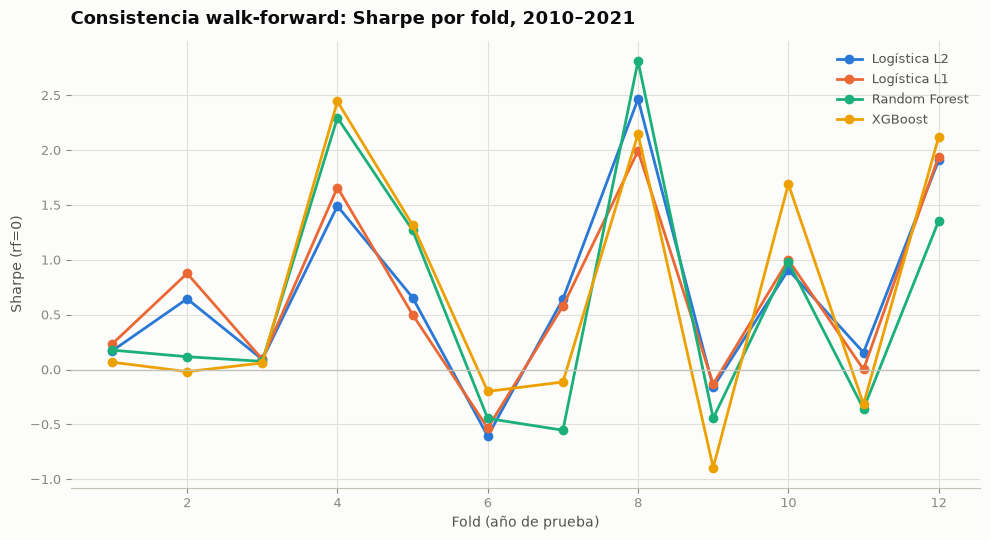

In [7]:
colores_modelo = dict(zip(candidatos.keys(), [
    viz.COLOR_BUY_AND_HOLD, viz.COLOR_DCA, viz.COLOR_SMA, viz.COLOR_MOMENTUM,
]))

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=viz.SURFACE)
ax.set_facecolor(viz.SURFACE)
for nombre in candidatos:
    sub = tabla_todos_folds[tabla_todos_folds["modelo"] == nombre]
    ax.plot(sub["fold"], sub["Sharpe (rf=0)"], marker="o", linewidth=2,
            color=colores_modelo[nombre], label=nombre)
ax.axhline(0, color=viz.BASELINE, linewidth=1)
ax.set_xlabel("Fold (año de prueba)", color=viz.INK_SECONDARY, fontsize=10)
ax.set_ylabel("Sharpe (rf=0)", color=viz.INK_SECONDARY, fontsize=10)
ax.set_title("Consistencia walk-forward: Sharpe por fold, 2010–2021",
             color=viz.INK_PRIMARY, fontsize=13, fontweight="bold", loc="left", pad=12)
ax.grid(True, color=viz.GRID, linewidth=0.8)
ax.tick_params(colors=viz.INK_MUTED, labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color(viz.BASELINE)
ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=viz.INK_SECONDARY)
plt.tight_layout()
plt.savefig("../outputs/figures/walkforward_consistencia_sharpe.png", dpi=160, facecolor=viz.SURFACE, bbox_inches="tight")
plt.show()

### Selección del modelo

**Criterio fijado de antemano** (para no elegir "a ojo" después de ver los resultados, la misma trampa de p-hacking que el walk-forward busca evitar): el modelo con mayor Sharpe promedio a través de los folds de desarrollo.

In [8]:
modelo_ganador = resumen_candidatos["sharpe_promedio"].idxmax()
print(f"Modelo elegido por walk-forward: {modelo_ganador}")
resumen_candidatos.loc[[modelo_ganador]]

Modelo elegido por walk-forward: Logística L2


,sharpe_promedio,sharpe_std,cagr_promedio,drawdown_promedio,operaciones_promedio
modelo,,,,,
Logística L2,0.696702,0.886789,0.063743,-0.107623,25.833333


## Entrenar el modelo ganador sobre todo el periodo de desarrollo

Ahora que el modelo está elegido (por walk-forward, sin haber visto el holdout todavía), se reentrena una sola vez con **todos** los datos de desarrollo (hasta 2021-12-31) antes de tocar el holdout.

In [9]:
en_desarrollo = fechas_xy <= FIN_DESARROLLO
X_dev, y_dev = X[en_desarrollo], y[en_desarrollo]

modelo_final = candidatos[modelo_ganador]()
modelo_final.fit(X_dev, y_dev)
print(f"Entrenado sobre {len(X_dev)} filas ({fechas_xy[en_desarrollo].min().date()} a {fechas_xy[en_desarrollo].max().date()})")

Entrenado sobre 7033 filas (1994-01-27 a 2021-12-31)


C:\Users\IngYa\jeffrey\proyecto-inversion\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Interpretabilidad

Ejecuto las señales manualmente — necesito poder ver *por qué* el modelo dice lo que dice, no solo confiar en una caja negra.

In [10]:
def obtener_importancias(modelo, nombres_features):
    estimador = list(modelo.named_steps.values())[-1] if hasattr(modelo, "named_steps") else modelo
    if hasattr(estimador, "coef_"):
        valores = estimador.coef_[0]
    else:
        valores = estimador.feature_importances_
    return pd.Series(valores, index=nombres_features).sort_values(key=abs, ascending=False)

importancias = obtener_importancias(modelo_final, X.columns)
importancias.to_frame("importancia / coeficiente")

,importancia / coeficiente
dist_sma200,-1.815506
sma50_vs_sma200,1.629340
dist_sma50,0.628980
volatilidad_63d,0.209339
volatilidad_21d,-0.156235
rsi_14,0.124154
retorno_21d,0.054865
retorno_1d,-0.028383
momentum_12m,-0.021307
retorno_5d,0.004696


## Evaluación en el holdout (2022 en adelante) — una sola vez

A partir de aquí no se vuelve a tocar ni el modelo ni las features. El holdout llega hasta ~21 días de trading antes del final de los datos disponibles (ahí es donde el target de 21 días deja de estar definido en `features.preparar_dataset` — no es una limitación real del modelo, solo de cómo se construyó el dataset de evaluación).

In [11]:
en_holdout = ~en_desarrollo
X_holdout = X[en_holdout]
df_holdout = df.loc[X_holdout.index]
holdout_inicio = df_holdout["fecha"].min()
holdout_fin = df_holdout["fecha"].max()
print(f"Holdout: {holdout_inicio.date()} a {holdout_fin.date()} ({len(df_holdout)} días de trading)")

pred_holdout = modelo_final.predict(X_holdout)
señal_ml = pd.Series(pred_holdout, index=X_holdout.index, dtype=float)

df_ml = backtest.recortar_periodo(df_holdout, señal_ml, holdout_inicio, holdout_fin)
df_ml, valor_ml = backtest.simular(df_ml, CAPITAL_TOTAL, COSTO_BPS)
fila_ml = backtest.resumen(df_ml, valor_ml, CAPITAL_TOTAL, f"ML ({modelo_ganador})")
fila_ml

Holdout: 2022-01-03 a 2026-08-28 (1168 días de trading)


{'Escenario': 'ML (Logística L2)',
 'Valor final (USD)': np.float64(12878.21984031719),
 'CAGR': np.float64(0.055879785741572485),
 'Drawdown máximo': np.float64(-0.18755234161457934),
 'Sharpe (rf=0)': np.float64(0.4882812714038632),
 'Sortino (rf=0)': np.float64(0.5423457301501395),
 'Operaciones': 94,
 '% tiempo invertido': np.float64(0.6258561643835616)}

### Los mismos benchmarks del Paso 1/2, sobre la misma ventana exacta del holdout

Para que la comparación sea justa, Buy & Hold, SMA, Momentum y RSI se recalculan aquí (mismo `costo_bps`, mismas fechas) — no se reusan los resultados de 2000–2026 del Paso 2, que cubren un periodo distinto.

In [12]:
reglas = {
    "Buy & Hold": strategies.señal_buy_and_hold,
    "SMA 50/200": strategies.señal_sma,
    "Momentum 12m": strategies.señal_momentum,
    "RSI(14) 30/70": strategies.señal_rsi,
}

filas_holdout = [fila_ml]
series_holdout = {f"ML ({modelo_ganador})": (df_ml["fecha"], valor_ml)}

for nombre, señal_fn in reglas.items():
    señal_completa = señal_fn(df)  # calculada sobre TODO df para que el warmup use historia real
    df_regla = backtest.recortar_periodo(df, señal_completa, holdout_inicio, holdout_fin)
    df_regla, valor_regla = backtest.simular(df_regla, CAPITAL_TOTAL, COSTO_BPS)
    filas_holdout.append(backtest.resumen(df_regla, valor_regla, CAPITAL_TOTAL, nombre))
    series_holdout[nombre] = (df_regla["fecha"], valor_regla)

resumen_holdout = pd.DataFrame(filas_holdout)
resumen_holdout

,Escenario,Valor final (USD),CAGR,Drawdown máximo,Sharpe (rf=0),Sortino (rf=0),Operaciones,% tiempo invertido
0,ML (Logística L2),12878.219840,0.055880,-0.187552,0.488281,0.542346,94,0.625856
1,Buy & Hold,17107.641372,0.122345,-0.245341,0.751558,1.040031,0,0.999144
2,SMA 50/200,15412.245607,0.097447,-0.187552,0.755912,0.909928,4,0.771404
3,Momentum 12m,14298.387494,0.079892,-0.226302,0.642174,0.707273,14,0.787671
4,RSI(14) 30/70,15418.551738,0.097543,-0.205611,0.731979,0.676980,10,0.377568


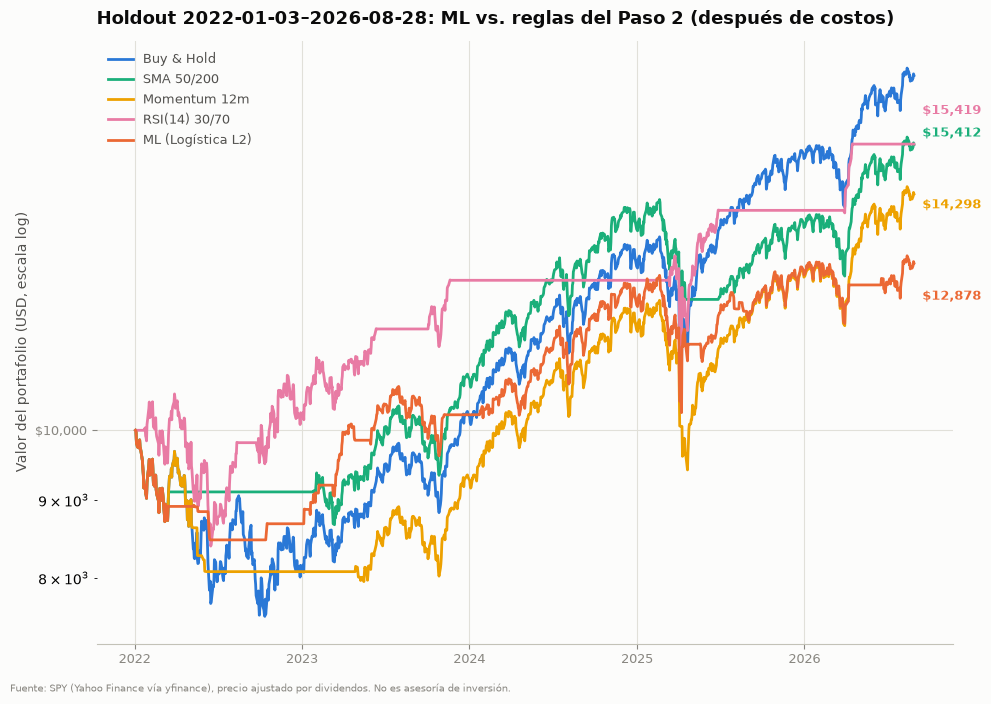

In [13]:
resumen_holdout.to_csv("../outputs/metrics/resumen_metricas_holdout_ml.csv", index=False)

serie_comparacion_holdout = None
for nombre, (fechas_s, valor_s) in series_holdout.items():
    columna = pd.DataFrame({"fecha": fechas_s.values, nombre: valor_s.values})
    serie_comparacion_holdout = (
        columna if serie_comparacion_holdout is None
        else serie_comparacion_holdout.merge(columna, on="fecha", how="outer")
    )
serie_comparacion_holdout = serie_comparacion_holdout.sort_values("fecha").reset_index(drop=True)
serie_comparacion_holdout.to_csv("../outputs/series/series_comparacion_holdout_ml.csv", index=False)

viz.graficar_todas_las_estrategias(
    serie_comparacion_holdout,
    series=[
        ("Buy & Hold", viz.COLOR_BUY_AND_HOLD, "Buy & Hold"),
        ("SMA 50/200", viz.COLOR_SMA, "SMA 50/200"),
        ("Momentum 12m", viz.COLOR_MOMENTUM, "Momentum 12m"),
        ("RSI(14) 30/70", viz.COLOR_RSI, "RSI(14) 30/70"),
        (f"ML ({modelo_ganador})", viz.COLOR_DCA, f"ML ({modelo_ganador})"),
    ],
    titulo=f"Holdout {holdout_inicio.date()}–{holdout_fin.date()}: ML vs. reglas del Paso 2 (después de costos)",
    archivo_salida="../outputs/figures/comparacion_holdout_ml_vs_reglas.png",
)

## Lectura

**La selección por walk-forward ya traía una señal de alerta.** Los 4 candidatos terminaron con un Sharpe promedio muy parecido entre sí (0.61–0.70 a través de los folds 2010–2021) y, en los cuatro casos, la desviación estándar entre folds fue **mayor que el promedio** (ej. Logística L2: media 0.70, std 0.89). Eso significa que ningún modelo tuvo un desempeño consistente año con año — el resultado de un fold cualquiera dice poco sobre el siguiente. Logística L2 ganó por un margen mínimo (0.697 vs. 0.692 de XGBoost), una diferencia perfectamente atribuible a ruido.

**En el holdout (2022 a mediados de 2026, nunca antes visto por el modelo), el resultado confirmó la advertencia:** la Logística L2 terminó **última de las cinco estrategias** en valor final, CAGR, Sharpe y Sortino — incluso peor que el RSI, que había sido la peor estrategia del Paso 2 sobre el periodo completo 2000–2026.

| Escenario | Valor final | CAGR | Drawdown máximo | Sharpe (rf=0) | Sortino (rf=0) | Operaciones |
|---|---|---|---|---|---|---|
| Buy & Hold | $17,108 | 12.23% | -24.53% | 0.75 | 1.04 | 0 |
| SMA 50/200 | $15,412 | 9.74% | -18.76% | 0.76 | 0.91 | 4 |
| RSI(14) 30/70 | $15,419 | 9.75% | -20.56% | 0.73 | 0.68 | 10 |
| Momentum 12m | $14,298 | 7.99% | -22.63% | 0.64 | 0.71 | 14 |
| **ML (Logística L2)** | **$12,878** | **5.59%** | -18.76% | 0.49 | 0.54 | **94** |

Lo más revelador es el número de operaciones: 94 en ~4.7 años (una cada ~12 días de trading), muchísimo más que las 4-14 de las reglas simples. Es la firma clásica de un modelo reaccionando a ruido en vez de a señal real — cada cambio de posición paga 5 bps de costo, y con esa frecuencia los costos por sí solos ya son una losa. (Nota aparte, sin sobre-interpretarla: el drawdown máximo del ML coincidió casi exactamente con el de SMA — ambos parecen haber salido del mercado en un punto similar durante la caída de 2022, una macro-corrección bastante uniforme donde distintas señales de tendencia coinciden más de lo usual.)

**Conclusión, siguiendo la regla que el proyecto se puso desde el Paso 1:** *"si el modelo no le gana de forma consistente y validada, el benchmark gana por defecto."* Ni la validación walk-forward ni el holdout mostraron evidencia de que este modelo (11 features técnicas clásicas + regresión logística, target binario a 21 días) capture algo explotable en SPY — **Buy & Hold sigue siendo la estrategia ganadora del proyecto hasta ahora.**

Esto no es un fracaso del experimento: es exactamente el resultado que la metodología (walk-forward + holdout intocado) está diseñada para producir de forma honesta, en vez de reportar un resultado casual que no se sostendría. Es consistente con la premisa de la que partí desde el principio: los mercados son razonablemente eficientes, y que el modelo le gane al benchmark es aspiracional, no garantizado. Vías concretas para explorar después (no implementadas aquí, para no volver a ajustar sobre el mismo holdout): features menos genéricas (ej. régimen de volatilidad, spreads entre activos), un target continuo en vez de binario, o aceptar que en un solo ETF líquido como SPY el filo de la ineficiencia explotable es, si acaso, muy delgado — y que la disciplina de riesgo del Paso 2 (SMA, en particular, con Sharpe muy cercano a Buy & Hold y bastante menor drawdown) puede ser un mejor punto de apoyo que perseguir más ML.